# Analysis: Oil Prices, GDP per Capita & Public Interest vs. EV Sales in the US

## Project Overview
This notebook investigates whether fluctuating oil prices, GDP per capita, and public search trends
drive electric vehicle (EV) sales in the United States.

### Data Sources
| Variable | Source | Notes |
|---|---|---|
| EV Sales (BEV + PHEV) | Argonne National Laboratory | Monthly, 2010–2026 |
| Crude Oil Price (WTI) | Yahoo Finance (yfinance) | Monthly closing price |
| GDP per Capita | FRED (A939RX0Q048SBEA) |  Monthly - US |
| Public Interest | Google Trends (CSV) | Search term: *electric car*, US only, 0–100 scale |
| Tariff Dummy | Derived | US tariffs on Chinese EV imports (after 1 May 24) |

### Notebook Structure
1. Load & Prepare EV Sales Data
2. Fetch Oil Prices & Read Google Trends
3. Fetch GDP Data & Merge All Sources
4. Normalize & Add Tariff Dummy
5. Exploratory Data Analysis (EDA)
6. Hypothesis Testing

## Step 1 — Load & Prepare EV Sales Data

In [38]:
import pandas as pd
#Read the CSV
csv_file_path = 'ev_sales.csv'
df_ev = pd.read_csv(csv_file_path)

#Parse date column
#Source format: 'Feb-26'  →  target: 2026-02-01
df_ev['Date'] = pd.to_datetime(df_ev['Month'], format='%b-%y')

#Target variable: BEV + PHEV = PEV
df_ev['Total_EV_Sales'] = df_ev['BEV'] + df_ev['PHEV']

#Keep only the columns we need
df_ev = df_ev[['Date', 'Total_EV_Sales']].set_index('Date')

#Sanity check
print(' First 5 Rows')
print(df_ev.head())
print('\nDataFrame Info')
print(df_ev.info())

 First 5 Rows
            Total_EV_Sales
Date                      
2010-12-01             345
2011-01-01             424
2011-02-01             364
2011-03-01             906
2011-04-01            1066

DataFrame Info
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 183 entries, 2010-12-01 to 2026-02-01
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Total_EV_Sales  183 non-null    int64
dtypes: int64(1)
memory usage: 2.9 KB
None


## Step 2 — Fetch Oil Prices & Read Google Trends

In [39]:
import yfinance as yf

#Oil Prices (WTI Crude, CL=F)
print('Fetching Oil Prices from Yahoo Finance')
oil_raw = yf.download('CL=F', start='2010-12-01', end='2026-03-01',interval='1mo', auto_adjust=True)

df_oil = oil_raw[['Close']].copy()
df_oil.columns = ['Oil_Price']

#Normalise - remove timezone, snap to month-start
df_oil.index = (df_oil.index.tz_localize(None).to_period('M').to_timestamp())

#Google Trends - skiping header lines
print('Reading Google Trends data from CSV')
df_trends = pd.read_csv('multiTimeline.csv', skiprows=2)
df_trends.columns = ['Month', 'Search_Trend']
df_trends['Date'] = pd.to_datetime(df_trends['Month'])
df_trends = df_trends[['Date', 'Search_Trend']].set_index('Date')
df_trends.index.name = 'Date'

#Checking the sources
print('\n Oil Prices (head) ')
print(df_oil.head())
print('\n Google Trends (head)')
print(df_trends.head())

[*********************100%***********************]  1 of 1 completed

Fetching Oil Prices from Yahoo Finance
Reading Google Trends data from CSV

 Oil Prices (head) 
             Oil_Price
Date                  
2010-12-01   91.379997
2011-01-01   92.190002
2011-02-01   96.970001
2011-03-01  106.720001
2011-04-01  113.930000

 Google Trends (head)
            Search_Trend
Date                    
2010-12-01            15
2011-01-01            20
2011-02-01            18
2011-03-01            20
2011-04-01            24


## Step 3 — Fetch GDP Data & Merge All Sources

In [40]:
import pandas_datareader.data as web

#GDP per Capita (FRED: A939RX0Q048SBEA)
print('Fetching GDP per Capita from FRED')
df_gdp = web.DataReader('A939RX0Q048SBEA', 'fred', '2010-10-01', '2026-03-01')
df_gdp.columns = ['GDP_per_Capita']
df_gdp.index.name = 'Date'
df_gdp = df_gdp.resample('MS').interpolate(method='linear')

# Merge: EV Sales (base) ← Oil ← Trends ← GDP
print('Merging all datasets')
df_final = df_ev.join([df_oil, df_trends, df_gdp], how='inner')

print('\n Merged DataFrame (head)')
print(df_final.head())
print('\n DataFrame Info')
print(df_final.info())

Fetching GDP per Capita from FRED
Merging all datasets

 Merged DataFrame (head)
            Total_EV_Sales   Oil_Price  Search_Trend  GDP_per_Capita
Date                                                                
2010-12-01             345   91.379997            15    54417.000000
2011-01-01             424   92.190002            20    54341.000000
2011-02-01             364   96.970001            18    54430.666667
2011-03-01             906  106.720001            20    54520.333333
2011-04-01            1066  113.930000            24    54610.000000

 DataFrame Info
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 153 entries, 2010-12-01 to 2025-10-01
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Total_EV_Sales  153 non-null    int64  
 1   Oil_Price       153 non-null    float64
 2   Search_Trend    153 non-null    int64  
 3   GDP_per_Capita  153 non-null    float64
dtypes: float64(2), int64(

## Step 4 — Add Tariff Dummy & Normalize
 Normalisation via MinMaxScaler so that features with very different magnitudes (e.g. GDP ~60 000 vs. Search Trend 0–100) do not dominate the analysis.

Tariff dummy variable: the US announced 100 % tariffs on Chinese EV imports in **May 2024**.

In [54]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

#Tariff dummy  (1 = tariff, 0 = no tariff)
df_final['Tariff_Active'] = np.where(df_final.index >= '2024-05-01', 1, 0)

#Min-Max normalisation [0,1]
cols_to_scale = ['Total_EV_Sales', 'Oil_Price', 'Search_Trend', 'GDP_per_Capita']

scaler = MinMaxScaler()
df_norm = df_final.copy()
df_norm[cols_to_scale] = scaler.fit_transform(df_norm[cols_to_scale])

#Verify (Tariff_Active = 1 period)
print('Normalised Dataset (tail)')
print(df_norm.tail())
print('\n Dataset Info')
print(df_norm.info())

Normalised Dataset (tail)
            Total_EV_Sales  Oil_Price  Search_Trend  GDP_per_Capita  \
Date                                                                  
2025-05-01        0.723640   0.441161      0.321839        0.970015   
2025-07-01        0.838506   0.530235      0.425287        0.998051   
2025-08-01        1.000000   0.475024      0.356322        0.998701   
2025-09-01        0.918855   0.457777      0.321839        0.999350   
2025-10-01        0.546862   0.443159      0.264368        1.000000   

            Tariff_Active  
Date                       
2025-05-01              1  
2025-07-01              1  
2025-08-01              1  
2025-09-01              1  
2025-10-01              1  

 Dataset Info
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 153 entries, 2010-12-01 to 2025-10-01
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Total_EV_Sales  153 non-null    float64
 1   Oi

---
## Step 5 — Exploratory Data Analysis (EDA)

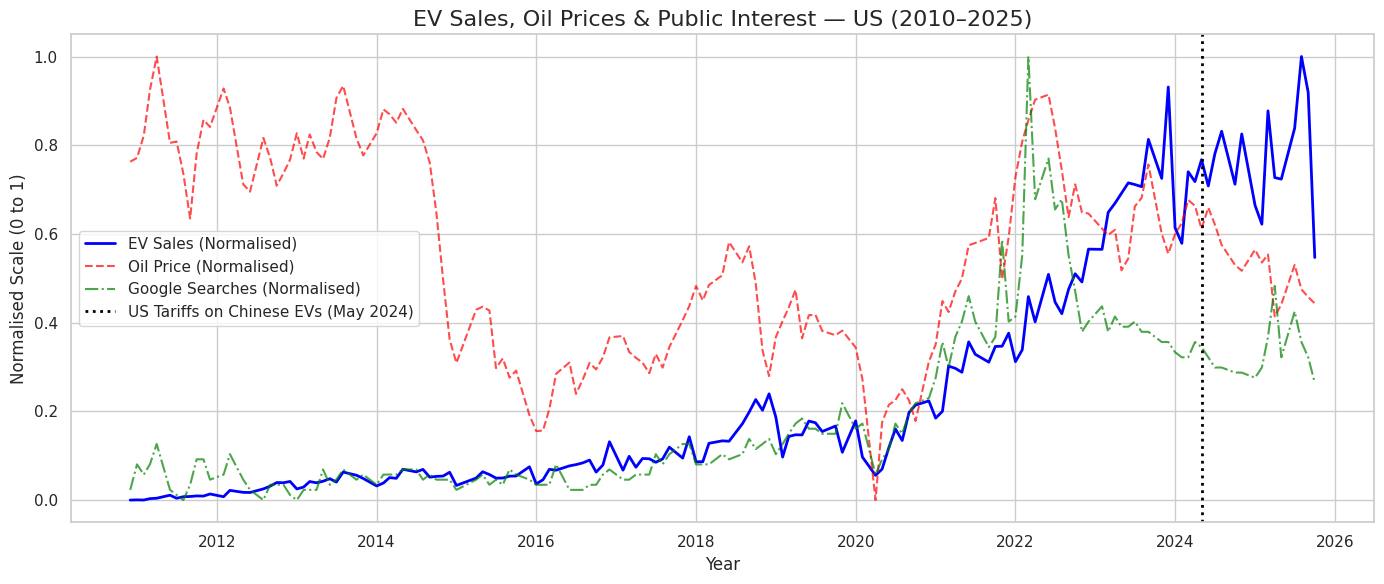

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_norm.index, df_norm['Total_EV_Sales'],label='EV Sales (Normalised)', color='blue', linewidth=2)
ax.plot(df_norm.index, df_norm['Oil_Price'],label='Oil Price (Normalised)', color='red', linestyle='--', alpha=0.7)
ax.plot(df_norm.index, df_norm['Search_Trend'],label='Google Searches (Normalised)', color='green', linestyle='-.', alpha=0.7)

# Vertical line: tariff activation
ax.axvline(pd.to_datetime('2024-05-01'), color='black', linestyle=':',linewidth=2, label='US Tariffs on Chinese EVs (May 2024)')

ax.set_title('EV Sales, Oil Prices & Public Interest — US (2010–2025)', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Normalised Scale (0 to 1)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

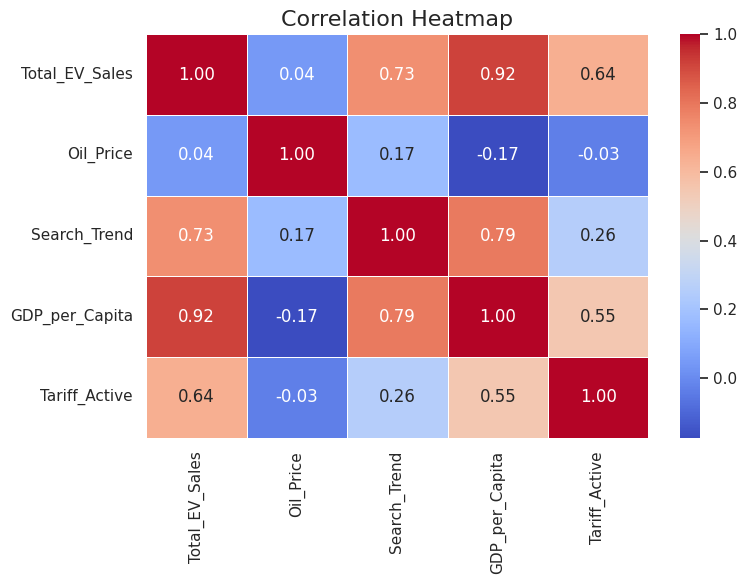

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))

corr = df_norm.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',linewidths=0.5, ax=ax)

ax.set_title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

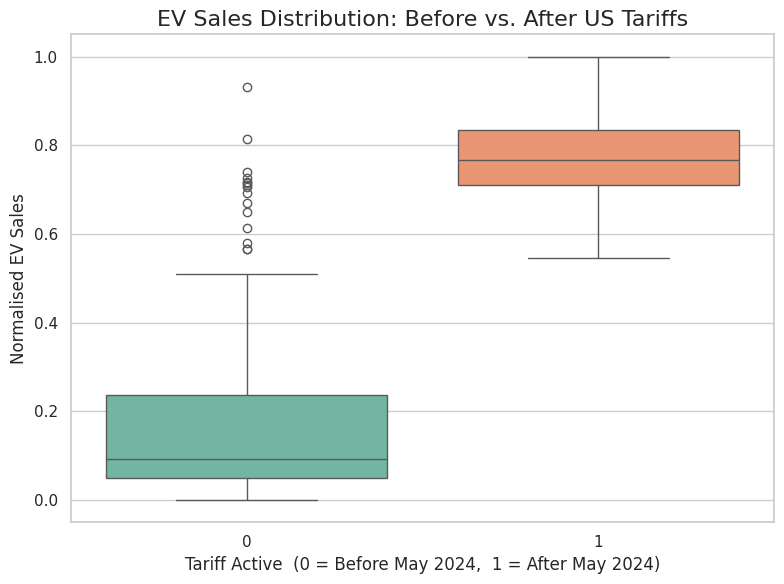

In [56]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df_norm,
    x='Tariff_Active',
    y='Total_EV_Sales',
    hue='Tariff_Active',
    palette='Set2',
    legend=False,
    ax=ax
)
ax.set_title('EV Sales Distribution: Before vs. After US Tariffs', fontsize=16)
ax.set_xlabel('Tariff Active  (0 = Before May 2024,  1 = After May 2024)', fontsize=12)
ax.set_ylabel('Normalised EV Sales', fontsize=12)
plt.tight_layout()
plt.show()

## Step 6 — Hypothesis Testing

### Test 1 — Pearson Correlation (continuous variables vs. EV Sales)
- H0: No significant linear relationship between the variable and EV Sales.
- H1: Significant linear relationship exists.
- Significance level α = 0.05.

### Test 2 — Welch's Independent T-Test (Tariff impact)
- H0: Mean EV sales are the same before and after tariff activation.
- H1: Mean EV sales are different before and after tariff activation.
- We use Welch's variant (equal_var=False) because sample sizes differ.

In [57]:
import scipy.stats as stats
# Pearson Correlations

print('HYPOTHESIS TEST 1: PEARSON CORRELATION')
print('H0: No significant linear relationship with EV Sales.')
print('H1: Significant linear relationship with EV Sales.\n')


for var in ['GDP_per_Capita', 'Search_Trend', 'Oil_Price']:
    r, p = stats.pearsonr(df_norm['Total_EV_Sales'], df_norm[var])
    result = 'REJECT H0' if p < 0.05 else 'FAIL TO REJECT H0'
    print(f'Variable : {var}')
    print(f'  r      = {r:.4f}')
    print(f'  p-value = {p:.4e}')
    print(f'  Result  : {result}\n')

#Welch's T-Test: Pre and Post Tariff EV Sales

print('HYPOTHESIS TEST 2: TARIFF IMPACT (Welch\'s T-Test)')
print('H0: Mean EV sales are the SAME before and after tariffs.')
print('H1: Mean EV sales DIFFER before and after tariffs.\n')

pre  = df_norm.loc[df_norm['Tariff_Active'] == 0, 'Total_EV_Sales']
post = df_norm.loc[df_norm['Tariff_Active'] == 1, 'Total_EV_Sales']

t_stat, p_val = stats.ttest_ind(pre, post, equal_var=False)

result = 'REJECT H0' if p_val < 0.05 else 'FAIL TO REJECT H0'
print(f'T-Statistic : {t_stat:.4f}')
print(f'P-Value     : {p_val:.4e}')
print(f'Result      : {result}')
if p_val < 0.05:
    direction = 'higher' if post.mean() > pre.mean() else 'lower'
    print(f'Average EV sales after May 2024 are {direction} than before.')

HYPOTHESIS TEST 1: PEARSON CORRELATION
H0: No significant linear relationship with EV Sales.
H1: Significant linear relationship with EV Sales.

Variable : GDP_per_Capita
  r      = 0.9161
  p-value = 7.9115e-62
  Result  : REJECT H0

Variable : Search_Trend
  r      = 0.7342
  p-value = 3.5702e-27
  Result  : REJECT H0

Variable : Oil_Price
  r      = 0.0433
  p-value = 5.9479e-01
  Result  : FAIL TO REJECT H0

HYPOTHESIS TEST 2: TARIFF IMPACT (Welch's T-Test)
H0: Mean EV sales are the SAME before and after tariffs.
H1: Mean EV sales DIFFER before and after tariffs.

T-Statistic : -16.3742
P-Value     : 3.8374e-15
Result      : REJECT H0
Average EV sales after May 2024 are higher than before.
